# Ablation Study — Two-Stream (E5 + E6a/b/c)

Phiên Kaggle 2: Kiểm tra xem Two-Stream tự thân và Two-Stream full pipeline.

| ID  | Tên | Depth | Loss | Warm-up | Clip | Sampler | Aug |
|-----|-----|-------|------|---------|------|---------|-----|
| E5  | Two-Stream (full) | 6 | Focal | ✓ | ✓ | ✓ | ✓ |
| E6a | Two-Stream bare | 8 | Focal | ✗ | ✗ | ✗ | ✗ |
| E6b | Two-Stream bare | 6 | Focal | ✗ | ✗ | ✗ | ✗ |
| E6c | Two-Stream bare | 4 | Focal | ✗ | ✗ | ✗ | ✗ |

**So sánh chính:** E6a/b/c vs E1 (single-stream, cùng không có tricks)
→ Trả lời câu hỏi: Two-Stream tự thân có giá trị hay không?

In [1]:
# ── Cell 1: Environment & paths ─────────────────────────────────────────────
import os
import subprocess
import sys
from pathlib import Path

try:
    from dotenv import load_dotenv
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'python-dotenv', '-q'], check=True)
    from dotenv import load_dotenv

_nb_dir = Path(globals().get('__vsc_ipynb_file__', __file__) if '__file__' in dir() else '.').resolve().parent
for _candidate in [_nb_dir / '.env', _nb_dir.parent / '.env', Path('.env')]:
    if _candidate.exists():
        load_dotenv(_candidate)
        print(f'Loaded .env from {_candidate}')
        break
else:
    print('No .env found')

REPO_DIR    = os.getenv('REPO_DIR',   '/kaggle/working/Yolo-ST-GCN')
BRANCH      = os.getenv('BRANCH',     'experiment-bonestream')
GYM288_PKL  = os.getenv('GYM288_PKL', '/kaggle/working/Gym288-skeleton/gym_288_skeleton.pkl')
GYM99_PKL   = os.getenv('GYM99_PKL',  '/kaggle/working/Gym99-from-Gym288/gym99_from_gym288.pkl')
OUT_BASE    = os.getenv('OUT_DIR',    'outputs/ablation_2s')
POLICY_PATH = '/kaggle/working/fx_aug_policy.json'

EPOCHS                  = 150
BATCH_SIZE              = 32
LR                      = '0.0005'
WARMUP_EPOCHS           = '8'
EARLY_STOPPING_PATIENCE = '12'

E6_DEPTHS  = [6]
E6_IDS     = {d: f'E6{chr(ord("a") + i)}' for i, d in enumerate(E6_DEPTHS)}
E6_DIRS    = {d: f'{OUT_BASE}/E6_2s_d{d}_bare' for d in E6_DEPTHS}
EXP_DIRS   = {E6_IDS[d]: E6_DIRS[d] for d in E6_DEPTHS}
EXP_DIRS['E5'] = f'{OUT_BASE}/E5'

EXP_LABELS = {
    'E5' : 'E5 — Two-Stream full (depth=6)',
    'E6b': 'E6b — Two-Stream bare (depth=6)',
}
COLORS = {'E5': '#2980b9', 'E6b': '#9b59b6'}
STYLES = {'E5': '-',       'E6b': '-.'}
WIDTHS = {'E5': 2.5,       'E6b': 1.8}

# E1 reference from single-stream notebook (fill in after running ablation_singlestream)
# E1_BEST_VAL = 0.0  # <-- paste the best val acc of E1 here for delta comparison

print(f'REPO_DIR = {REPO_DIR}')
print(f'OUT_BASE = {OUT_BASE}')

No .env found
REPO_DIR = /kaggle/working/Yolo-ST-GCN
OUT_BASE = outputs/ablation_2s


In [2]:
# ── Cell 2: Repo setup ────────────────────────────────────────────────────────
REPO_URL = 'https://github.com/schizocatto/Yolo-ST-GCN.git'

if not Path(REPO_DIR).exists():
    print('Cloning repo...')
    subprocess.run(
        ['git', 'clone', '-b', BRANCH, '--single-branch', REPO_URL, REPO_DIR],
        check=True,
    )
else:
    print('Repo exists — pulling latest...')
    subprocess.run(['git', '-C', REPO_DIR, 'fetch', 'origin', BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'checkout', BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'pull', 'origin', BRANCH], check=True)

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print('Working dir:', os.getcwd())

Cloning repo...


Cloning into '/kaggle/working/Yolo-ST-GCN'...


Working dir: /kaggle/working/Yolo-ST-GCN


In [3]:
# ── Cell 3: Download Gym288 dataset ───────────────────────────────────────────
if Path(GYM288_PKL).exists():
    print(f'Gym288 pickle found: {GYM288_PKL}')
else:
    print('Downloading from HuggingFace...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'huggingface_hub', '-q'], check=True)
    from huggingface_hub import snapshot_download
    download_dir = Path(GYM288_PKL).parent
    download_dir.mkdir(parents=True, exist_ok=True)
    snapshot_download(
        repo_id='Lozumi/Gym288-skeleton',
        repo_type='dataset',
        local_dir=str(download_dir),
        local_dir_use_symlinks=False,
    )
    pkl_candidates = sorted(download_dir.rglob('*.pkl'))
    if not pkl_candidates:
        raise FileNotFoundError('No .pkl found after Gym288 download.')
    GYM288_PKL = str(pkl_candidates[0])
    print(f'Downloaded: {GYM288_PKL}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Downloaded: /kaggle/working/Gym288-skeleton/gym_288_skeleton.pkl


In [4]:
# ── Cell 4: Create FX augmentation policy ─────────────────────────────────────
import json

fx_policy = {
    "0": {
        "horizontal_flip_prob": 0.5,
        "scale_prob": 0.2,
        "scale_range": [0.95, 1.05],
        "random_shift": False,
        "random_move": False,
        "noise_std": 0.0,
        "joint_drop_prob": 0.0,
        "subsample_prob": 0.0
    },
    "1": {
        "horizontal_flip_prob": 0.5,
        "scale_prob": 0.5,
        "scale_range": [0.9, 1.1],
        "random_shift": True,
        "random_move": True,
        "move_angle": 5.0,
        "move_scale": 0.05,
        "move_trans": 0.0,
        "noise_std": 0.005,
        "joint_drop_prob": 0.05,
        "subsample_prob": 0.3,
        "subsample_factor_range": [0.9, 1.1]
    },
    "2": {
        "horizontal_flip_prob": 0.5,
        "scale_prob": 0.8,
        "scale_range": [0.85, 1.15],
        "random_shift": True,
        "random_move": True,
        "move_angle": 10.0,
        "move_scale": 0.1,
        "move_trans": 0.0,
        "noise_std": 0.01,
        "joint_drop_prob": 0.1,
        "subsample_prob": 0.5,
        "subsample_factor_range": [0.8, 1.2],
        "temporal_reverse_prob": 0.0
    }
}

Path(POLICY_PATH).parent.mkdir(parents=True, exist_ok=True)
with open(POLICY_PATH, 'w') as f:
    json.dump(fx_policy, f, indent=4)

print(f'Augmentation policy saved: {POLICY_PATH}')

Augmentation policy saved: /kaggle/working/fx_aug_policy.json


---
## Phần 1a: E5 — Two-Stream full pipeline (depth=6)

Đủ tất cả: Focal Loss + Warm-up + Gradient Clipping + Weighted Sampler + Augmentation.

In [5]:
# ── E5: Two-Stream (Full pipeline) ────────────────────────────────────────────
import importlib

OUT = EXP_DIRS['E5']
checkpoint = Path(OUT) / 'stgcn_gym99_coco18_2s_d6_expert_FX.pth'
if checkpoint.exists():
    print(f'[E5] Checkpoint found, skipping: {checkpoint}')
else:
    sys.argv = [
        'train_gym99.py',
        '--auto_build_from_gym288',
        '--gym288_dataset_path',     GYM288_PKL,
        '--dataset_path',            GYM99_PKL,
        '--out_dir',                 OUT,
        '--apparatus',               'FX',
        '--epochs',                  str(EPOCHS),
        '--batch_size',              str(BATCH_SIZE),
        '--lr',                      LR,
        '--warmup_epochs',           WARMUP_EPOCHS,
        '--early_stopping_patience', EARLY_STOPPING_PATIENCE,
        '--num_workers',             '2',
        '--joint_spec_name',         'coco18',
        '--use_two_stream',                              # <-- Two-Stream
        '--model_depth',             '6',
        '--loss_name',               'focal',
        '--focal_alpha_mode',        'sqrt_inverse',
        '--center_norm',
        '--grad_clip_norm',          '1.0',
        '--use_weighted_sampler',
        '--use_augment_feeder',
        '--aug_config_path',         POLICY_PATH,
        '--weight_decay',            '0.0005',
        '--save_every_epochs',       '10',
    ]
    import scripts.train_gym99 as _train
    importlib.reload(_train)
    print('>>> Training E5 — Two-Stream (Full pipeline), depth=6...')
    _train.main()
    print('\n✅ E5 done.')

>>> Training E5 — Two-Stream (Full pipeline), depth=6...
Building Gym99-from-Gym288 pickle...
Gym99 mapping stats: direct=34240 minus1=1625 plus1=800 train=27624 test=9041
Device: cuda
Loading Gym99-skeleton dataset...
[apparatus=FX] class range [6, 40] → local classes [0, 34]  train=5824  val=2411
[corrupt filter] train: 5824 → 5280 (removed 544)
[corrupt filter] val:   2411 → 2181 (removed 230)
Loaded 36665 samples  train=5280  test=2181
[info] Applying per-frame center normalization (center joint = 17)...
num_classes=35 (apparatus=FX, local labels 0-34)
[info] Using in-memory tensors; forcing num_workers=0 to avoid dataloader overhead.
[info] Loaded custom augmentation policy from: /kaggle/working/fx_aug_policy.json

[SkeletonFeeder] Augmentation tier assignment (35 classes, 5280 samples)
  Tier 0 [Majority (light)] — 18 classes, 3928 samples (74.4%)
      class   16: 130 samples
      class    1: 131 samples
      class   19: 132 samples
      class   15: 132 samples
      class   

Epoch 1/150  train_loss=3.2743  train_acc=0.0453  val_loss=2.6842  val_acc=0.0261  val_f1=0.0165


Epoch 2/150  train_loss=2.2179  train_acc=0.1966  val_loss=1.6110  val_acc=0.2013  val_f1=0.1957


Epoch 3/150  train_loss=1.4830  train_acc=0.3587  val_loss=1.1964  val_acc=0.3274  val_f1=0.3510


Epoch 4/150  train_loss=1.1554  train_acc=0.4475  val_loss=1.0325  val_acc=0.3952  val_f1=0.4036


...

Epoch 116/150  train_loss=0.0181  train_acc=0.9917  val_loss=0.1656  val_acc=0.8955  val_f1=0.8810


Epoch 117/150  train_loss=0.0134  train_acc=0.9943  val_loss=0.1639  val_acc=0.9060  val_f1=0.8932


Epoch 118/150  train_loss=0.0130  train_acc=0.9938  val_loss=0.1844  val_acc=0.8895  val_f1=0.8692


Epoch 119/150  train_loss=0.0148  train_acc=0.9934  val_loss=0.1644  val_acc=0.8987  val_f1=0.8863


Epoch 120/150  train_loss=0.0128  train_acc=0.9953  val_loss=0.1717  val_acc=0.8996  val_f1=0.8787
Saved periodic checkpoint: outputs/ablation_2s/E5/stgcn_gym99_coco18_2s_d6_expert_FX_epoch120.pth
[early stopping] No val_loss improvement for 12 epochs. Stopping at epoch 120.
[early stopping] Restored best weights (val_loss=0.1594)
Saved weights: outputs/ablation_2s/E5/stgcn_gym99_coco18_2s_d6_expert_FX.pth
Test Top-1 Accuracy: 0.8991
Test Macro-F1     : 0.8848

✅ E5 done.


---
## Phần 1b: Two-Stream bare — chưa có optimization techniques

Mục tiêu: Kiểm tra xem bản thân kiến trúc Two-Stream (không warm-up, không clip,
không weighted sampler, không augment) đã vượt trội hơn Baseline hay chưa.
Thử trên 3 độ sâu 8 / 6 / 4 để thấy ảnh hưởng của depth trong Two-Stream.

| ID  | Stream | Depth | Loss  | Warm-up | Grad Clip | Sampler | Aug |
|-----|--------|-------|-------|---------|-----------|---------|-----|
| E6a | Two    | 8     | Focal | ✗       | ✗         | ✗       | ✗   |
| E6b | Two    | 6     | Focal | ✗       | ✗         | ✗       | ✗   |
| E6c | Two    | 4     | Focal | ✗       | ✗         | ✗       | ✗   |

In [6]:
# ── Config cho nhóm E6 (Two-Stream bare) ─────────────────────────────────────
E6_DEPTHS = [8, 6, 4]
E6_DIRS   = {d: f'{OUT_BASE}/E6_2s_d{d}_bare' for d in E6_DEPTHS}
E6_IDS    = {d: f'E6{chr(ord("a") + i)}' for i, d in enumerate(E6_DEPTHS)}  # E6a, E6b, E6c

# Cập nhật vào dict tổng EXP_DIRS và EXP_LABELS để dùng ở phần so sánh
for d in E6_DEPTHS:
    eid = E6_IDS[d]
    EXP_DIRS[eid]   = E6_DIRS[d]
    EXP_LABELS[eid] = f'{eid} — Two-Stream bare (depth={d})'
    COLORS[eid]     = {8: '#8e44ad', 6: '#9b59b6', 4: '#d7bde2'}[d]  # tím nhạt/đậm
    STYLES[eid]     = {8: '--', 6: '-.', 4: ':'}[d]
    WIDTHS[eid]     = 1.8

print('E6 dirs:')
for d in E6_DEPTHS:
    print(f'  {E6_IDS[d]}: {E6_DIRS[d]}')

E6 dirs:
  E6a: outputs/ablation_2s/E6_2s_d8_bare
  E6b: outputs/ablation_2s/E6_2s_d6_bare
  E6c: outputs/ablation_2s/E6_2s_d4_bare


In [7]:
# # ── E6a: Two-Stream bare, depth=8 ─────────────────────────────────────────────
# import importlib

# DEPTH = 8
# EID   = E6_IDS[DEPTH]
# OUT   = E6_DIRS[DEPTH]
# checkpoint = Path(OUT) / f'stgcn_gym99_coco18_2s_d{DEPTH}_expert_FX.pth'
# if checkpoint.exists():
#     print(f'[{EID}] Checkpoint found, skipping: {checkpoint}')
# else:
#     sys.argv = [
#         'train_gym99.py',
#         '--auto_build_from_gym288',
#         '--gym288_dataset_path',     GYM288_PKL,
#         '--dataset_path',            GYM99_PKL,
#         '--out_dir',                 OUT,
#         '--apparatus',               'FX',
#         '--epochs',                  str(EPOCHS),
#         '--batch_size',              str(BATCH_SIZE),
#         '--lr',                      LR,
#         '--early_stopping_patience', EARLY_STOPPING_PATIENCE,
#         '--num_workers',             '2',
#         '--joint_spec_name',         'coco18',
#         '--use_two_stream',
#         '--model_depth',             str(DEPTH),
#         '--loss_name',               'focal',
#         '--focal_alpha_mode',        'sqrt_inverse',
#         '--center_norm',
#         '--weight_decay',            '0.0005',
#         '--save_every_epochs',       '10',
#     ]
#     import scripts.train_gym99 as _train
#     importlib.reload(_train)
#     print(f'>>> Training {EID} — Two-Stream bare depth={DEPTH}...')
#     _train.main()
#     print(f'\n✅ {EID} done.')

In [8]:
# ── E6b: Two-Stream bare, depth=6 ─────────────────────────────────────────────
import importlib

DEPTH = 6
EID   = E6_IDS[DEPTH]
OUT   = E6_DIRS[DEPTH]
checkpoint = Path(OUT) / f'stgcn_gym99_coco18_2s_d{DEPTH}_expert_FX.pth'
if checkpoint.exists():
    print(f'[{EID}] Checkpoint found, skipping: {checkpoint}')
else:
    sys.argv = [
        'train_gym99.py',
        '--auto_build_from_gym288',
        '--gym288_dataset_path',     GYM288_PKL,
        '--dataset_path',            GYM99_PKL,
        '--out_dir',                 OUT,
        '--apparatus',               'FX',
        '--epochs',                  str(EPOCHS),
        '--batch_size',              str(BATCH_SIZE),
        '--lr',                      LR,
        '--early_stopping_patience', EARLY_STOPPING_PATIENCE,
        '--num_workers',             '2',
        '--joint_spec_name',         'coco18',
        '--use_two_stream',
        '--model_depth',             str(DEPTH),
        '--loss_name',               'focal',
        '--focal_alpha_mode',        'sqrt_inverse',
        '--center_norm',
        '--weight_decay',            '0.0005',
        '--save_every_epochs',       '10',
    ]
    import scripts.train_gym99 as _train
    importlib.reload(_train)
    print(f'>>> Training {EID} — Two-Stream bare depth={DEPTH}...')
    _train.main()
    print(f'\n✅ {EID} done.')

>>> Training E6b — Two-Stream bare depth=6...
Building Gym99-from-Gym288 pickle...
Gym99 mapping stats: direct=34240 minus1=1625 plus1=800 train=27624 test=9041
Device: cuda
Loading Gym99-skeleton dataset...
[apparatus=FX] class range [6, 40] → local classes [0, 34]  train=5824  val=2411
[corrupt filter] train: 5824 → 5280 (removed 544)
[corrupt filter] val:   2411 → 2181 (removed 230)
Loaded 36665 samples  train=5280  test=2181
[info] Applying per-frame center normalization (center joint = 17)...
num_classes=35 (apparatus=FX, local labels 0-34)
[info] Using in-memory tensors; forcing num_workers=0 to avoid dataloader overhead.
DataLoader num_workers=0  two_stream=True  train_data_mode=standard
Model: TwoStream_STGCN  depth=6
[train] optimizer=adam  lr=0.0005  weight_decay=0.0005  grad_clip_norm=1.0


Epoch 1/150  train_loss=1.7128  train_acc=0.2759  val_loss=1.2229  val_acc=0.4585  val_f1=0.3593


Epoch 2/150  train_loss=1.0802  train_acc=0.4333  val_loss=1.0389  val_acc=0.4686  val_f1=0.3839


Epoch 3/150  train_loss=0.8393  train_acc=0.5119  val_loss=0.9790  val_acc=0.4415  val_f1=0.4290


Epoch 4/150  train_loss=0.7038  train_acc=0.5538  val_loss=0.6818  val_acc=0.5374  val_f1=0.4939


...

Epoch 47/150  train_loss=0.0526  train_acc=0.9595  val_loss=0.2326  val_acc=0.8638  val_f1=0.8373


Epoch 48/150  train_loss=0.0550  train_acc=0.9559  val_loss=0.2493  val_acc=0.8560  val_f1=0.8249


Epoch 49/150  train_loss=0.0502  train_acc=0.9597  val_loss=0.2374  val_acc=0.8624  val_f1=0.8370


Epoch 50/150  train_loss=0.0504  train_acc=0.9544  val_loss=0.2543  val_acc=0.8624  val_f1=0.8316
Saved periodic checkpoint: outputs/ablation_2s/E6_2s_d6_bare/stgcn_gym99_coco18_2s_d6_expert_FX_epoch50.pth


Epoch 51/150  train_loss=0.0510  train_acc=0.9623  val_loss=0.2848  val_acc=0.8336  val_f1=0.8136
[early stopping] No val_loss improvement for 12 epochs. Stopping at epoch 51.
[early stopping] Restored best weights (val_loss=0.2064)
Saved weights: outputs/ablation_2s/E6_2s_d6_bare/stgcn_gym99_coco18_2s_d6_expert_FX.pth
Test Top-1 Accuracy: 0.8762
Test Macro-F1     : 0.8614

✅ E6b done.


In [9]:
# # ── E6c: Two-Stream bare, depth=4 ─────────────────────────────────────────────
# import importlib

# DEPTH = 4
# EID   = E6_IDS[DEPTH]
# OUT   = E6_DIRS[DEPTH]
# checkpoint = Path(OUT) / f'stgcn_gym99_coco18_2s_d{DEPTH}_expert_FX.pth'
# if checkpoint.exists():
#     print(f'[{EID}] Checkpoint found, skipping: {checkpoint}')
# else:
#     sys.argv = [
#         'train_gym99.py',
#         '--auto_build_from_gym288',
#         '--gym288_dataset_path',     GYM288_PKL,
#         '--dataset_path',            GYM99_PKL,
#         '--out_dir',                 OUT,
#         '--apparatus',               'FX',
#         '--epochs',                  str(EPOCHS),
#         '--batch_size',              str(BATCH_SIZE),
#         '--lr',                      LR,
#         '--early_stopping_patience', EARLY_STOPPING_PATIENCE,
#         '--num_workers',             '2',
#         '--joint_spec_name',         'coco18',
#         '--use_two_stream',
#         '--model_depth',             str(DEPTH),
#         '--loss_name',               'focal',
#         '--focal_alpha_mode',        'sqrt_inverse',
#         '--center_norm',
#         '--weight_decay',            '0.0005',
#         '--save_every_epochs',       '10',
#     ]
#     import scripts.train_gym99 as _train
#     importlib.reload(_train)
#     print(f'>>> Training {EID} — Two-Stream bare depth={DEPTH}...')
#     _train.main()
#     print(f'\n✅ {EID} done.')

---
## Phần 2: So sánh kết quả Two-Stream

Load histories và so sánh E5 vs E6a/b/c.

**Câu hỏi chính cần trả lời:**
- E6b (Two-Stream bare depth=6) có vượt E1 (Single-stream depth=6) không?
- Depth nào phù hợp nhất cho Two-Stream bare?
- E5 (full pipeline) cải thiện bao nhiêu so với E6b?

In [10]:
# ── Load histories ───────────────────────────────────────────────────────────
import json

HISTORIES = {}
METRICS   = {}

# E5
for eid, exp_dir in EXP_DIRS.items():
    h_path = Path(exp_dir) / 'history.json'
    m_path = Path(exp_dir) / 'metrics_train_gym99.json'
    if h_path.exists():
        with open(h_path) as f:
            HISTORIES[eid] = json.load(f)
        print(f'[{eid}] Loaded ({len(HISTORIES[eid]["val_acc"])} epochs)')
    else:
        print(f'[{eid}] history.json not found.')
    if m_path.exists():
        with open(m_path) as f:
            METRICS[eid] = json.load(f)

print(f'Loaded: {list(HISTORIES.keys())}')

[E6a] history.json not found.
[E5] Loaded (120 epochs)
[E6b] Loaded (51 epochs)
[E6c] history.json not found.
Loaded: ['E5', 'E6b']


In [11]:
# ── Two-Stream bare vs Baseline & E1 — focused comparison ─────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

focus_ids = ['E0', 'E1'] + [E6_IDS[d] for d in E6_DEPTHS if E6_IDS[d] in HISTORIES]
focus_ids = [e for e in focus_ids if e in HISTORIES]

if len(focus_ids) < 2:
    print('Cần ít nhất 2 experiments để so sánh.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Two-Stream bare vs Baseline — Does Two-Stream help without tricks?',
                 fontsize=12, fontweight='bold')

    for ax, (key, title) in zip(axes, [('val_acc', 'Val Accuracy'), ('val_loss', 'Val Loss')]):
        for eid in focus_ids:
            h = HISTORIES[eid]
            if key not in h:
                continue
            epochs = range(1, len(h[key]) + 1)
            ax.plot(
                epochs, h[key],
                color=COLORS.get(eid, 'black'),
                linestyle=STYLES.get(eid, '-'),
                linewidth=WIDTHS.get(eid, 1.5),
                label=EXP_LABELS.get(eid, eid),
            )
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    plt.tight_layout()
    out_png = Path(OUT_BASE) / 'twostream_bare_vs_baseline.png'
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_png}')

    # Bảng nhỏ
    print(f'\n{"Exp":<6}  {"Mô tả":<40}  {"Best Val":>10}  {"Delta vs E1":>12}')
    print('-' * 75)
    base = max(HISTORIES['E1']['val_acc']) if 'E1' in HISTORIES else 0
    for eid in focus_ids:
        best  = max(HISTORIES[eid]['val_acc'])
        delta = best - base
        print(f'{eid:<6}  {EXP_LABELS.get(eid, eid):<40}  {best:>10.4f}  {delta:>+12.4f}')

Cần ít nhất 2 experiments để so sánh.


In [12]:
# ── Cell: Bảng tổng kết định lượng ───────────────────────────────────────────
import json

EXP_LABELS = {
    'E0': 'E0 — Baseline (depth=10, CE)',
    'E1': 'E1 — Focal Loss (depth=6)',
    'E2': 'E2 — +Warm-up & Clip',
    'E3': 'E3 — +Weighted Sampler',
    'E4': 'E4 — +Augmentation',
    'E5': 'E5 — Two-Stream (full)',
}

print(f'{"Exp":<5}  {"Mô tả":<35}  {"Best Val Acc":>12}  {"@Epoch":>7}  '
      f'{"Final Val":>10}  {"Final Train":>12}  {"Gap":>8}  {"Macro F1":>9}')
print('-' * 100)

for eid in ['E0', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6a', 'E6b', 'E6c']:
    if eid not in HISTORIES:
        print(f'{eid:<5}  {EXP_LABELS.get(eid, eid):<35}  {"(no data)":>12}')
        continue
    h = HISTORIES[eid]
    best_val   = max(h['val_acc'])
    best_epoch = h['val_acc'].index(best_val) + 1
    final_val  = h['val_acc'][-1]
    final_tr   = h['train_acc'][-1]
    gap        = final_tr - final_val

    macro_f1 = '—'
    if eid in METRICS:
        macro_f1 = f"{METRICS[eid].get('macro_f1', 0):.4f}"

    label = EXP_LABELS.get(eid, eid)
    print(f'{eid:<5}  {label:<35}  {best_val:>12.4f}  {best_epoch:>7}  '
          f'{final_val:>10.4f}  {final_tr:>12.4f}  {gap:>+8.4f}  {macro_f1:>9}')

Exp    Mô tả                                Best Val Acc   @Epoch   Final Val   Final Train       Gap   Macro F1
----------------------------------------------------------------------------------------------------
E0     E0 — Baseline (depth=10, CE)            (no data)
E1     E1 — Focal Loss (depth=6)               (no data)
E2     E2 — +Warm-up & Clip                    (no data)
E3     E3 — +Weighted Sampler                  (no data)
E4     E4 — +Augmentation                      (no data)
E5     E5 — Two-Stream (full)                     0.9069      107      0.8996        0.9953   +0.0957     0.8848
E6a    E6a                                     (no data)
E6b    E6b                                        0.8762       39      0.8336        0.9623   +0.1287     0.8614
E6c    E6c                                     (no data)


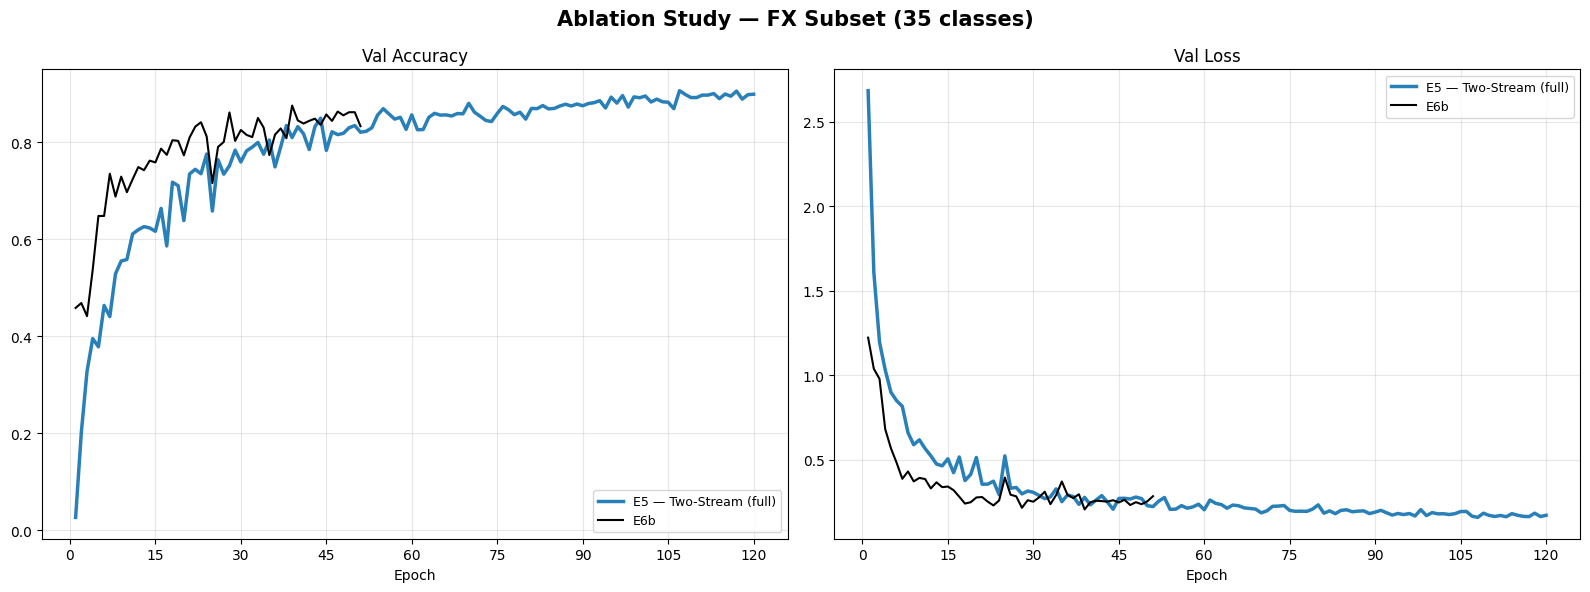

Saved: outputs/ablation_2s/ablation_curves.png


In [13]:
# ── Cell: Training curves — Val Accuracy & Val Loss cho tất cả experiments ────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

COLORS = {
    'E0': '#95a5a6',   # xám — baseline
    'E1': '#e74c3c',   # đỏ
    'E2': '#e67e22',   # cam
    'E3': '#f1c40f',   # vàng
    'E4': '#27ae60',   # xanh lá
    'E5': '#2980b9',   # xanh dương — full pipeline
}
STYLES = {'E0': ':', 'E1': '--', 'E2': '-.', 'E3': '--', 'E4': '-', 'E5': '-'}
WIDTHS = {'E0': 1.5, 'E1': 1.5, 'E2': 1.5, 'E3': 1.5, 'E4': 2.0, 'E5': 2.5}

if not HISTORIES:
    print('No histories loaded — run training and load cells first.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Ablation Study — FX Subset (35 classes)', fontsize=15, fontweight='bold')

    for ax, (key, title) in zip(axes, [('val_acc', 'Val Accuracy'), ('val_loss', 'Val Loss')]):
        for eid, h in HISTORIES.items():
            if key not in h:
                continue
            epochs = range(1, len(h[key]) + 1)
            label = EXP_LABELS.get(eid, eid)
            ax.plot(
                epochs, h[key],
                color=COLORS.get(eid, 'black'),
                linestyle=STYLES.get(eid, '-'),
                linewidth=WIDTHS.get(eid, 1.5),
                label=label,
            )
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=9, loc='lower right' if 'acc' in key else 'upper right')
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    plt.tight_layout()
    out_png = Path(OUT_BASE) / 'ablation_curves.png'
    out_png.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_png}')

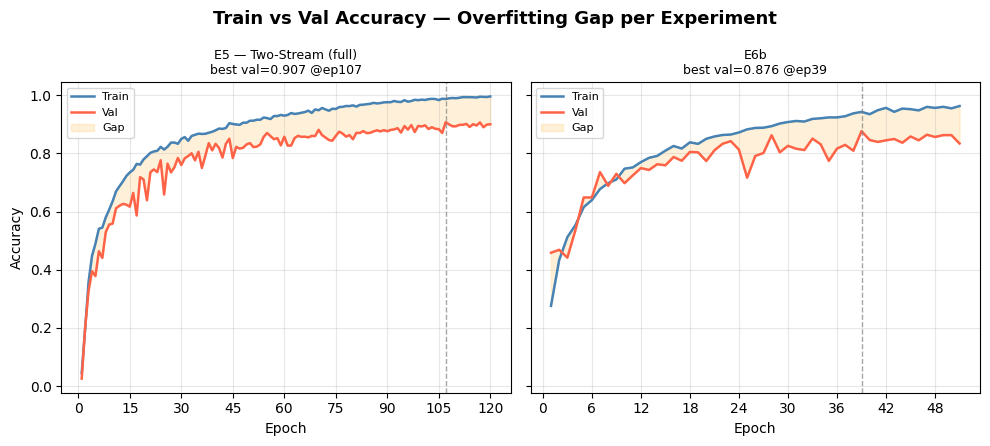

Saved: outputs/ablation_2s/ablation_gap.png


In [14]:
# ── Cell: Overfitting gap — so sánh Train vs Val accuracy ─────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

if not HISTORIES:
    print('No histories loaded.')
else:
    n = len(HISTORIES)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5), sharey=True)
    if n == 1:
        axes = [axes]
    fig.suptitle('Train vs Val Accuracy — Overfitting Gap per Experiment', fontsize=13, fontweight='bold')

    for ax, (eid, h) in zip(axes, HISTORIES.items()):
        epochs = range(1, len(h['train_acc']) + 1)
        ax.plot(epochs, h['train_acc'], color='steelblue', linewidth=1.8, label='Train')
        ax.plot(epochs, h['val_acc'],   color='tomato',    linewidth=1.8, label='Val')
        ax.fill_between(epochs, h['val_acc'], h['train_acc'],
                        alpha=0.15, color='orange', label='Gap')

        best_val   = max(h['val_acc'])
        best_epoch = h['val_acc'].index(best_val) + 1
        ax.axvline(best_epoch, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        label = EXP_LABELS.get(eid, eid)
        ax.set_title(f'{label}\nbest val={best_val:.3f} @ep{best_epoch}', fontsize=9)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    axes[0].set_ylabel('Accuracy')
    plt.tight_layout()
    out_png = Path(OUT_BASE) / 'ablation_gap.png'
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_png}')

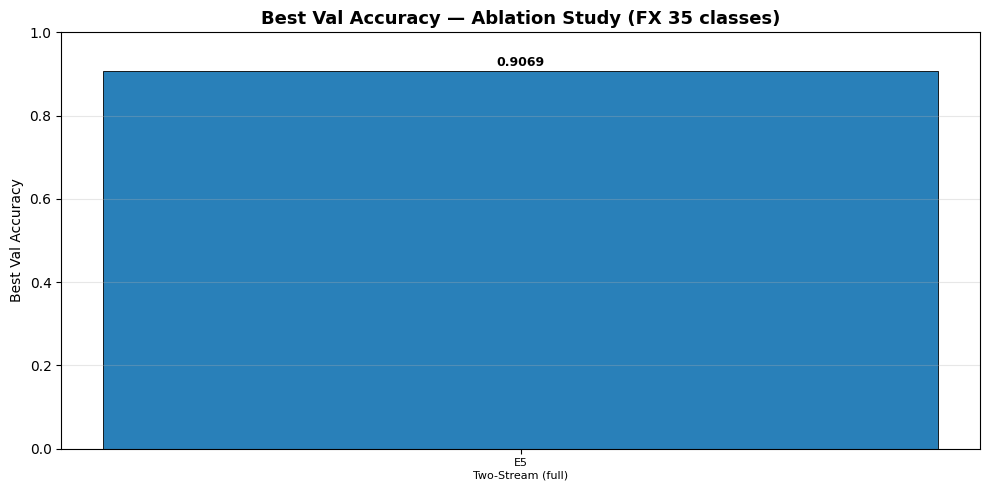

Saved: outputs/ablation_2s/ablation_bar.png


In [15]:
# ── Cell: Bar chart — Best Val Accuracy per experiment ───────────────────────
import matplotlib.pyplot as plt
import numpy as np

if not HISTORIES:
    print('No histories loaded.')
else:
    eids   = [eid for eid in ['E0','E1','E2','E3','E4','E5'] if eid in HISTORIES]
    labels = [EXP_LABELS.get(e, e) for e in eids]
    bests  = [max(HISTORIES[e]['val_acc']) for e in eids]
    colors = [COLORS.get(e, 'gray') for e in eids]

    # Shorten labels for bar chart
    short_labels = [e for e in eids]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(short_labels, bests, color=colors, edgecolor='black', linewidth=0.6)
    ax.set_title('Best Val Accuracy — Ablation Study (FX 35 classes)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Best Val Accuracy')
    ax.set_ylim(0, min(1.0, max(bests) * 1.15))
    ax.grid(axis='y', alpha=0.3)

    for bar, val, eid in zip(bars, bests, eids):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Add full labels as x-tick tooltips (rotated)
    ax.set_xticks(range(len(eids)))
    ax.set_xticklabels([f'{eid}\n{EXP_LABELS[eid].split("—")[1].strip()[:30]}'
                        for eid in eids], fontsize=8)

    plt.tight_layout()
    out_png = Path(OUT_BASE) / 'ablation_bar.png'
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_png}')

In [16]:
# ── Delta: so sánh tất cả với E5 (full pipeline) ────────────────────────────
if 'E5' not in HISTORIES:
    print('[skip] E5 not loaded.')
else:
    base_val = max(HISTORIES['E5']['val_acc'])
    print(f'Reference (E5) best val acc = {base_val:.4f}\n')
    print(f'{"Exp":<6}  {"Mo ta":<40}  {"Best Val":>10}  {"Delta vs E5":>12}')
    print('-' * 72)
    for eid in ['E5', 'E6a', 'E6b', 'E6c']:
        if eid not in HISTORIES:
            continue
        best  = max(HISTORIES[eid]['val_acc'])
        delta = best - base_val
        label = EXP_LABELS.get(eid, eid)
        marker = ' <- reference' if eid == 'E5' else ''
        print(f'{eid:<6}  {label:<40}  {best:>10.4f}  {delta:>+12.4f}{marker}')

Reference (E5) best val acc = 0.9069

Exp     Mo ta                                       Best Val   Delta vs E5
------------------------------------------------------------------------
E5      E5 — Two-Stream (full)                        0.9069       +0.0000 <- reference
E6b     E6b                                           0.8762       -0.0307
